# Soil Moisture Classification, 3 km Patches

Data and model artifacts are intentionally external to this repository. Configure their locations in `.env` before running the notebook.


In [ ]:
# Reproducible project paths (launch Jupyter from the repository root)
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "README.md").is_file():
    PROJECT_ROOT = next(
        (parent for parent in PROJECT_ROOT.parents if (parent / "README.md").is_file()),
        PROJECT_ROOT,
    )

load_dotenv(PROJECT_ROOT / ".env")
DATA_ROOT = Path(os.getenv("SOIL_DATA_DIR", PROJECT_ROOT / "data")).expanduser()
MODEL_ROOT = Path(os.getenv("SOIL_MODEL_DIR", PROJECT_ROOT / "models")).expanduser()
OUTPUT_ROOT = Path(os.getenv("SOIL_OUTPUT_DIR", PROJECT_ROOT / "outputs")).expanduser()

if not DATA_ROOT.is_absolute():
    DATA_ROOT = PROJECT_ROOT / DATA_ROOT
if not MODEL_ROOT.is_absolute():
    MODEL_ROOT = PROJECT_ROOT / MODEL_ROOT
if not OUTPUT_ROOT.is_absolute():
    OUTPUT_ROOT = PROJECT_ROOT / OUTPUT_ROOT

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / ".cache").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / ".cache").mkdir(parents=True, exist_ok=True)


In [3]:
import os, glob, math, cv2
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torchvision.models as models
from torchvision.models.efficientnet import EfficientNet_V2_S_Weights

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

import tifffile as tiff
from PIL import Image, ImageOps
import uuid

In [4]:
import os
import pandas as pd
from datetime import datetime

# Paths
csv_path = str(DATA_ROOT / "weather" / "Dair_Alla_2015_2025.csv")
base_dir = str(DATA_ROOT / "sentinel_downloads_3km")

# Load and process the CSV
df = pd.read_csv(csv_path, parse_dates=["date"])

# Keep daytime only (06–18 UTC)
df = df[(df["date"].dt.hour >= 6) & (df["date"].dt.hour <= 18)]

# Compute daily mean soil moisture
df["date"] = df["date"].dt.date
daily_df = df.groupby("date")["soil_moisture_0_to_7cm"].mean().reset_index()

# Traverse all subfolders recursively to find TIFFs
image_records = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".tiff"):
            try:
                # Assumes filename is like "2022-01-01.tiff"
                date_obj = datetime.strptime(file[:-5], "%Y-%m-%d").date()
                image_path = os.path.join(root, file)
                image_records.append((date_obj, image_path))
            except ValueError:
                continue

# Create DataFrame of image paths and dates
images_df = pd.DataFrame(image_records, columns=["date", "path"])

# Merge with daily soil moisture values
final_df = pd.merge(images_df, daily_df, on="date", how="inner")

# Final output
print(f"Matched image-label pairs: {len(final_df)}")

Matched image-label pairs: 830


In [5]:
# Create 3-class target 
def moisture_to_class(x: float) -> int:
    if x < 0.10:
        return 0
    elif x <= 0.20:
        return 1
    else:
        return 2

final_df["label_cls"] = final_df["soil_moisture_0_to_7cm"].apply(moisture_to_class)

print("\nOriginal label distribution:\n", final_df["label_cls"].value_counts().sort_index())

class_0_df = final_df[final_df["label_cls"] == 0]
to_remove = class_0_df.sample(n=500, random_state=42)
final_df = final_df.drop(to_remove.index)

final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nUpdated label distribution after removal and shuffle:\n", final_df["label_cls"].value_counts().sort_index())


Original label distribution:
 label_cls
0    628
1    128
2     74
Name: count, dtype: int64

Updated label distribution after removal and shuffle:
 label_cls
0    128
1    128
2     74
Name: count, dtype: int64


In [6]:
IMG_SIZE = 224

def preprocess_tiff(path: str, size: int = 224) -> torch.Tensor:
    """Return (2, size, size) float32 tensor scaled 0-1."""
    with rasterio.open(path) as src:
        img = src.read()                                # (2,H,W)
    img = np.array([(b - b.min()) / (b.max() - b.min() + 1e-6) for b in img])
    img = np.array([cv2.resize(b, (size, size), interpolation=cv2.INTER_LINEAR)
                    for b in img], dtype=np.float32)
    return torch.from_numpy(img)

In [7]:
# Dataset
class MoistureDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = preprocess_tiff(row["path"], IMG_SIZE)
        label = torch.tensor(row["label_cls"], dtype=torch.long)
        return img, label

# Stratified split
train_df, temp_df = train_test_split(
    final_df, test_size=0.3, stratify=final_df["label_cls"], random_state=42)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label_cls"], random_state=42)

# Datasets
train_ds = MoistureDataset(train_df)
val_ds   = MoistureDataset(val_df)
test_ds  = MoistureDataset(test_df)

# Weighted sampler for class imbalance (optional)
class_counts = train_df["label_cls"].value_counts().sort_index()
class_weights = 1. / class_counts
weights = train_df["label_cls"].map(class_weights).values
train_sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders
BATCH = 16

train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=train_sampler,
                      num_workers=4, pin_memory=True)

val_dl   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                      num_workers=4, pin_memory=True)

test_dl  = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                      num_workers=4, pin_memory=True)

In [8]:
#  Model – EfficientNet-V2-S (2-band input, 3-class head)

NUM_CLASSES = 3
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
LR          = 1e-4
N_EPOCHS    = 200

model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)

# tweak first conv (from 3→2 channels)
orig_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(
        in_channels=2,
        out_channels=orig_conv.out_channels,
        kernel_size=orig_conv.kernel_size,
        stride=orig_conv.stride,
        padding=orig_conv.padding,
        bias=orig_conv.bias is not None)
with torch.no_grad():
    model.features[0][0].weight[:] = orig_conv.weight[:, :2]

# replace classifier
n_in = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(0.5, True),
                                 nn.Linear(n_in, NUM_CLASSES))
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 165MB/s] 


In [9]:
#  Train

opt      = optim.AdamW(model.parameters(), lr=LR)
loss_fn  = nn.CrossEntropyLoss()

best_acc, patience, counter = 0.0, 20, 0
best_model_path = str(MODEL_ROOT / "classification_3km.pth")

for epoch in range(1, N_EPOCHS + 1):
    # training loop
    model.train()
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()

    # validation
    model.eval(); v_logits, v_truths = [], []
    with torch.no_grad():
        for x, y in val_dl:
            v_logits.append(model(x.to(DEVICE)).cpu())
            v_truths.append(y)
    v_logits = torch.cat(v_logits)
    v_truths = torch.cat(v_truths)
    acc = (v_logits.argmax(1) == v_truths).float().mean().item()

    print(f"Epoch {epoch:03d} | Val ACC = {acc*100:5.2f}%")
    if acc > best_acc:
        best_acc, counter = acc, 0
        torch.save(model.state_dict(), best_model_path)
        print("  ↳ new best – model saved")
    else:
        counter += 1
        if counter >= patience:
            print("\nEarly stopping.")
            break

Epoch 001 | Val ACC = 44.90%
  ↳ new best – model saved
Epoch 002 | Val ACC = 59.18%
  ↳ new best – model saved
Epoch 003 | Val ACC = 59.18%
Epoch 004 | Val ACC = 65.31%
  ↳ new best – model saved
Epoch 005 | Val ACC = 67.35%
  ↳ new best – model saved
Epoch 006 | Val ACC = 67.35%
Epoch 007 | Val ACC = 71.43%
  ↳ new best – model saved
Epoch 008 | Val ACC = 71.43%
Epoch 009 | Val ACC = 63.27%
Epoch 010 | Val ACC = 71.43%
Epoch 011 | Val ACC = 75.51%
  ↳ new best – model saved
Epoch 012 | Val ACC = 75.51%
Epoch 013 | Val ACC = 71.43%
Epoch 014 | Val ACC = 65.31%
Epoch 015 | Val ACC = 71.43%
Epoch 016 | Val ACC = 69.39%
Epoch 017 | Val ACC = 67.35%
Epoch 018 | Val ACC = 71.43%
Epoch 019 | Val ACC = 77.55%
  ↳ new best – model saved
Epoch 020 | Val ACC = 75.51%
Epoch 021 | Val ACC = 73.47%
Epoch 022 | Val ACC = 71.43%
Epoch 023 | Val ACC = 73.47%
Epoch 024 | Val ACC = 77.55%
Epoch 025 | Val ACC = 75.51%
Epoch 026 | Val ACC = 77.55%
Epoch 027 | Val ACC = 79.59%
  ↳ new best – model saved
E


 TEST ACCURACY = 70.00%

 Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.75      0.81        20
    Moderate       0.59      0.68      0.63        19
        High       0.64      0.64      0.64        11

    accuracy                           0.70        50
   macro avg       0.70      0.69      0.69        50
weighted avg       0.72      0.70      0.71        50



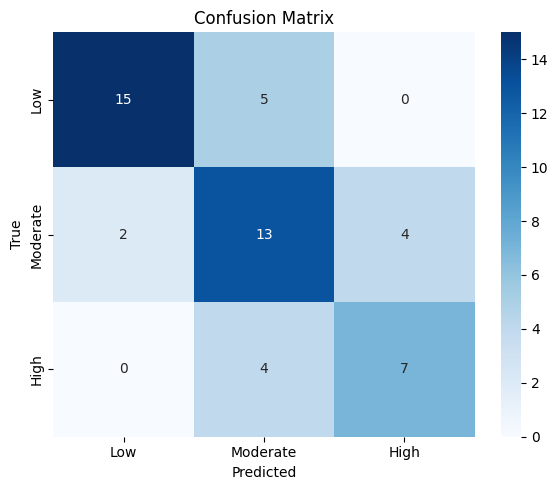


 Macro Avg Precision: 0.7032
 Macro Avg Recall:    0.6902
 Macro Avg F1-score:  0.6938


In [10]:
# Test set evaluation with full classification metrics

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns

# Load best model and run predictions
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model.eval(); t_logits, t_truths = [], []

with torch.no_grad():
    for x, y in test_dl:
        t_logits.append(model(x.to(DEVICE)).cpu())
        t_truths.append(y)

t_logits = torch.cat(t_logits)
t_truths = torch.cat(t_truths)
preds    = t_logits.argmax(1)

# Basic metrics
test_acc = accuracy_score(t_truths, preds)
print(f"\n TEST ACCURACY = {test_acc*100:.2f}%")

# Classification report
print("\n Classification Report:")
print(classification_report(t_truths, preds, target_names=["Low", "Moderate", "High"]))

# Confusion Matrix
cm = confusion_matrix(t_truths, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Moderate", "High"],
            yticklabels=["Low", "Moderate", "High"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Additional metrics (optional)
macro_precision = precision_score(t_truths, preds, average='macro')
macro_recall    = recall_score(t_truths, preds, average='macro')
macro_f1        = f1_score(t_truths, preds, average='macro')

print(f"\n Macro Avg Precision: {macro_precision:.4f}")
print(f" Macro Avg Recall:    {macro_recall:.4f}")
print(f" Macro Avg F1-score:  {macro_f1:.4f}")

In [11]:
#  Single-image prediction helper

CLASS_NAMES = {0: "Low (0-10%)", 1: "Moderate (10-20%)", 2: "High (>20%)"}

def predict_image_class(path: str):
    x = preprocess_tiff(path, IMG_SIZE).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        cls_id = model(x).argmax(1).item()
    return cls_id, CLASS_NAMES[cls_id]

# Example:
# cid, cname = predict_image_class(str(DATA_ROOT / "sample.tiff"))
# print(cname)

In [12]:
# 10 | Batch-merge B8A/B11 and classify

input_dir = str(DATA_ROOT / "testing" / "classification_3km")
output_dir = str(OUTPUT_ROOT / "classification_3km_merged")
os.makedirs(output_dir, exist_ok=True)

all_files = glob.glob(os.path.join(input_dir, '**', '*.tiff'), recursive=True)
grouped   = defaultdict(dict)
for f in all_files:
    date = os.path.basename(f).split('_')[0]
    if   'B8A' in f: grouped[date]['B8A'] = f
    elif 'B11' in f: grouped[date]['B11'] = f

predictions = []
for date, bands in grouped.items():
    if 'B8A' in bands and 'B11' in bands:
        with rasterio.open(bands['B8A']) as src_b8a:
            b8a = src_b8a.read(1); profile = src_b8a.profile
        with rasterio.open(bands['B11']) as src_b11:
            b11 = src_b11.read(1)

        stacked = np.stack([b8a, b11])
        profile.update(count=2)

        merged_path = os.path.join(output_dir, f"{date}_merged.tif")
        with rasterio.open(merged_path, 'w', **profile) as dst:
            dst.write(stacked)

        cid, cname = predict_image_class(merged_path)
        predictions.append((date, cname))
        print(f"{date}: {cname}")
    else:
        print(f"Skipping {date} (missing band)")

# to DataFrame
pred_df = pd.DataFrame(predictions, columns=["date","prediction"])
print("\nFinal predictions head:\n", pred_df.head())

2025-02-08: Moderate (10–30)
2025-07-18: Low (0–10)
2025-02-28: Moderate (10–30)
2025-03-25: Low (0–10)
2025-05-24: Low (0–10)
2025-05-09: Moderate (10–30)
2025-01-29: Moderate (10–30)
2025-02-18: Moderate (10–30)
2025-07-13: Low (0–10)

Final predictions head:
          date        prediction
0  2025-02-08  Moderate (10–30)
1  2025-07-18        Low (0–10)
2  2025-02-28  Moderate (10–30)
3  2025-03-25        Low (0–10)
4  2025-05-24        Low (0–10)


2025-02-08: Moderate (10–30)


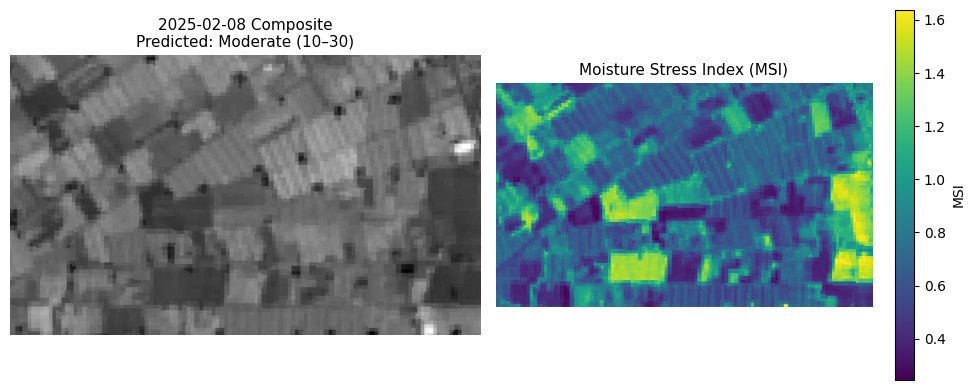

2025-07-18: Low (0–10)


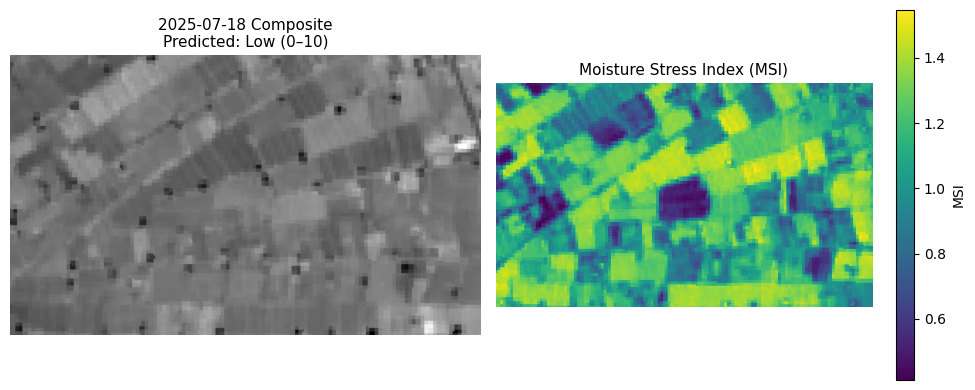

2025-02-28: Moderate (10–30)


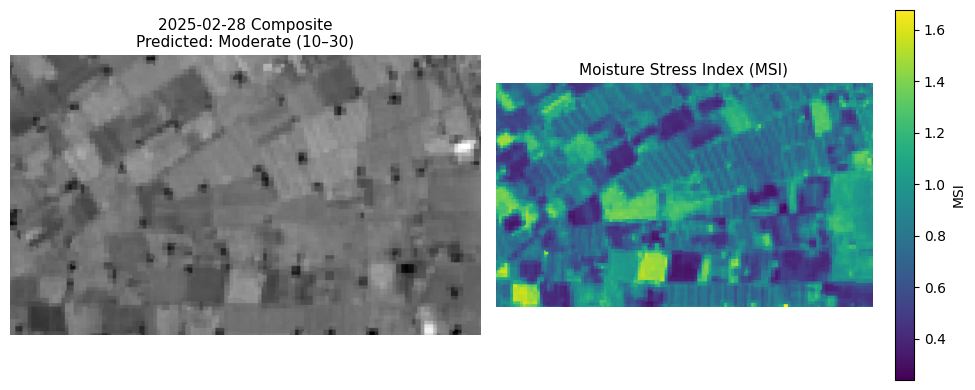

2025-03-25: Low (0–10)


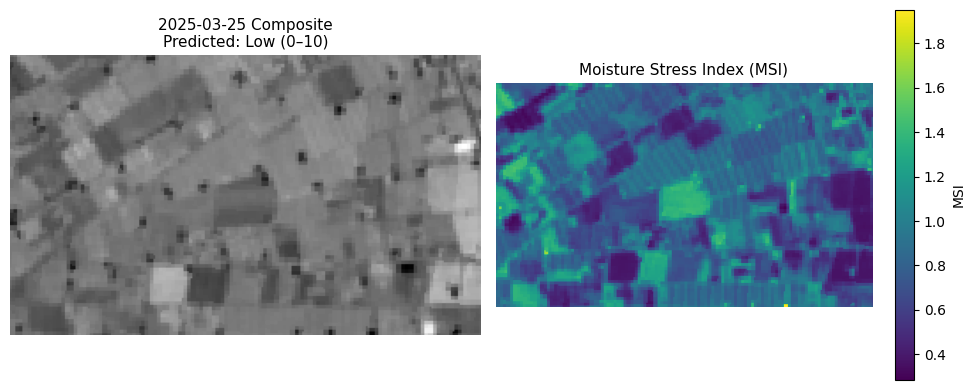

2025-05-24: Low (0–10)


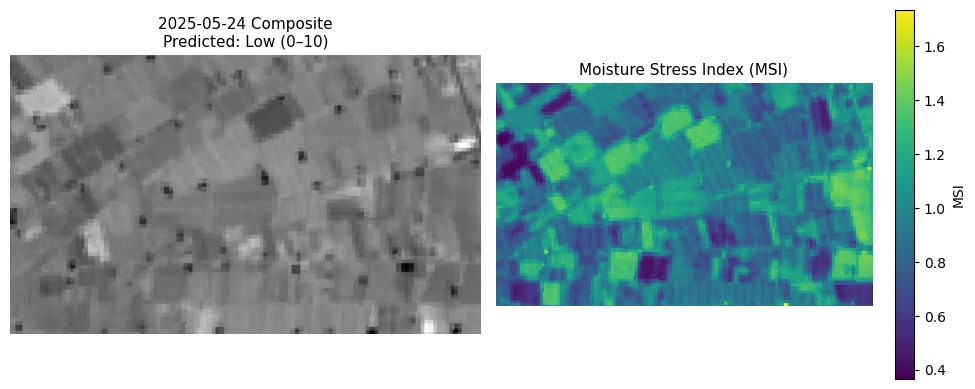

2025-05-09: Moderate (10–30)


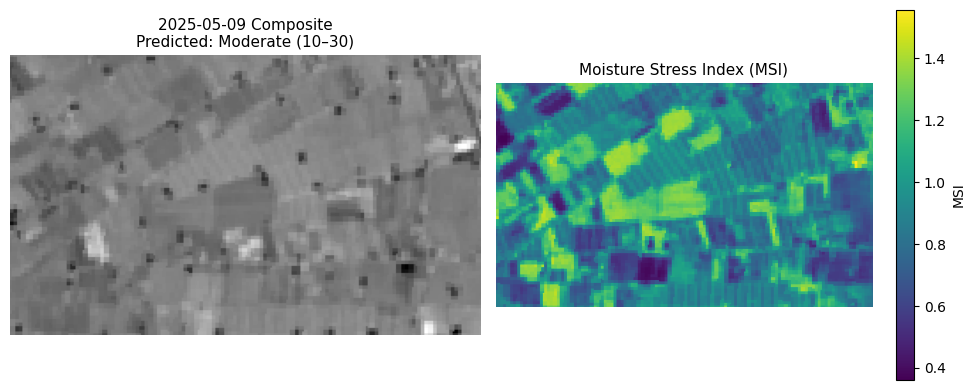

2025-01-29: Moderate (10–30)


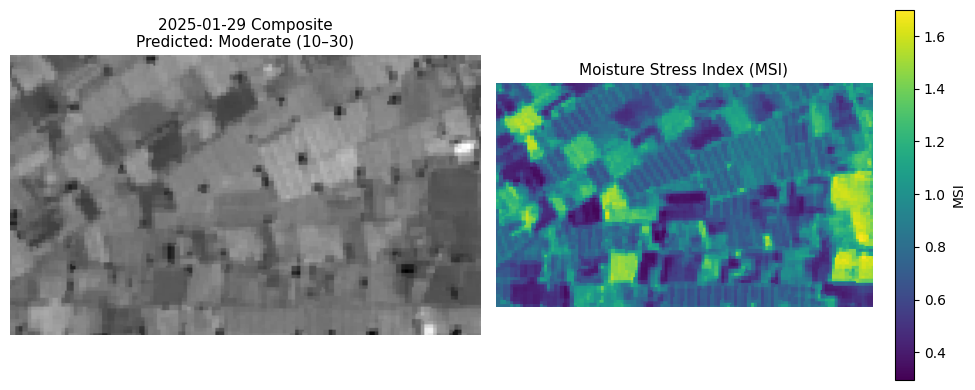

2025-02-18: Moderate (10–30)


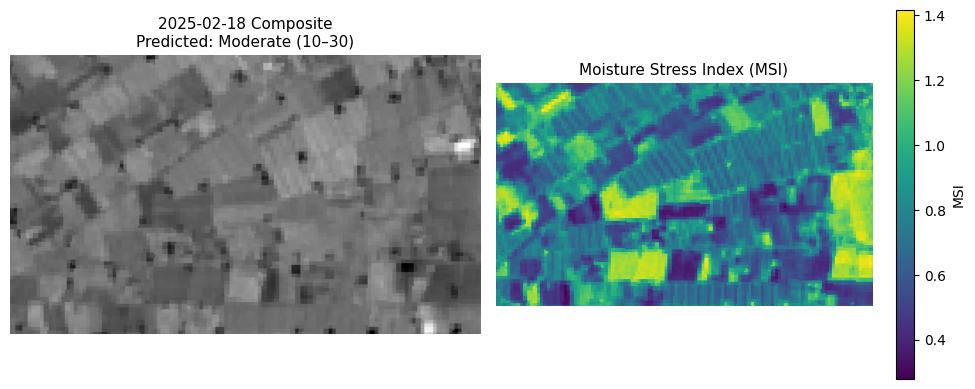

2025-07-13: Low (0–10)


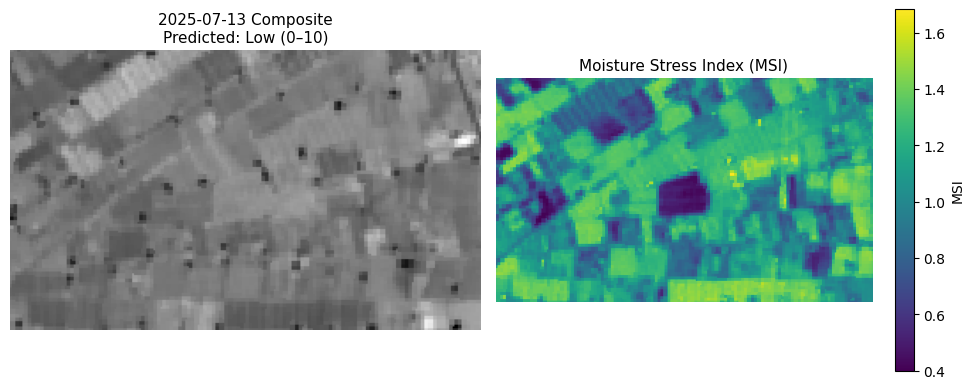


Final predictions head:
          date        prediction
0  2025-02-08  Moderate (10–30)
1  2025-07-18        Low (0–10)
2  2025-02-28  Moderate (10–30)
3  2025-03-25        Low (0–10)
4  2025-05-24        Low (0–10)


In [13]:
# 10 | Batch-merge B8A/B11 → Classify → Visualize
input_dir = str(DATA_ROOT / "testing" / "classification_3km")
output_dir = str(OUTPUT_ROOT / "classification_3km_merged")
os.makedirs(output_dir, exist_ok=True)

all_files = glob.glob(os.path.join(input_dir, '**', '*.tiff'), recursive=True)
grouped   = defaultdict(dict)

for f in all_files:
    date = os.path.basename(f).split('_')[0]
    if   'B8A' in f: grouped[date]['B8A'] = f
    elif 'B11' in f: grouped[date]['B11'] = f

predictions = []

for date, bands in grouped.items():
    if 'B8A' in bands and 'B11' in bands:
        with rasterio.open(bands['B8A']) as src_b8a:
            b8a = src_b8a.read(1).astype(np.float32)
            profile = src_b8a.profile
        with rasterio.open(bands['B11']) as src_b11:
            b11 = src_b11.read(1).astype(np.float32)

        stacked = np.stack([b8a, b11])
        profile.update(count=2)

        merged_path = os.path.join(output_dir, f"{date}_merged.tif")
        with rasterio.open(merged_path, 'w', **profile) as dst:
            dst.write(stacked)

        # Predict class
        cid, cname = predict_image_class(merged_path)
        predictions.append((date, cname))
        print(f"{date}: {cname}")

        # ─── Visualization ───
        composite = (b8a + b11) / 2
        msi = b11 / (b8a + 1e-6)
        msi = np.clip(msi, 0, 10)

        plt.figure(figsize=(10, 4))

        # Grayscale composite
        plt.subplot(1, 2, 1)
        plt.imshow(composite, cmap='gray')
        plt.title(f"{date} Composite\nPredicted: {cname}", fontsize=11)
        plt.axis('off')

        # Moisture Stress Index (B11/B8A)
        plt.subplot(1, 2, 2)
        plt.imshow(msi, cmap='viridis')
        plt.title("Moisture Stress Index (MSI)", fontsize=11)
        plt.axis('off')
        plt.colorbar(label='MSI')

        plt.tight_layout()
        plt.show()

    else:
        print(f"Skipping {date} (missing band)")

# Convert to DataFrame
pred_df = pd.DataFrame(predictions, columns=["date", "prediction"])
print("\nFinal predictions head:\n", pred_df.head())